In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from ipywidgets import IntSlider, interact

rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False

df = pd.read_csv("mayday_preprocessed.csv")


piece.csv   
        osa病人
        患有阻塞性睡眠呼吸暂停（Obstructive Sleep Apnea，OSA，全称阻塞性睡眠呼吸暂停低通气综合征 OSAHS） 的患者，核心是睡眠时上气道反复塌陷、堵塞，导致反复呼吸暂停 / 低通气、间歇性缺氧、睡眠碎片化

piece1.csv 

In [7]:
y = df.ied_final

In [8]:
y

0         -6997.078939
1         -4608.250314
2         -2139.843834
3          -766.550341
4          2247.948285
              ...     
7909623    -813.295718
7909624    -876.884238
7909625    -991.339857
7909626    -732.737540
7909627    -216.153441
Name: ied_final, Length: 7909628, dtype: float64

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

y = -1. * df['ied_final'].values
ymin, ymax = np.nanmin(y), np.nanmax(y)

@interact(
    start=IntSlider(min=0, max=len(y)-200, step=30, value=0, description='start idx'),
    window=IntSlider(min=200, max=7900000, step=100, value=500, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    t = np.arange(start, end) / 100.0
    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(t, y[start:end], 'o-', linewidth=1, markersize=2)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IED (high-pass)')
    # ax.set_ylim([ymin, ymax])

    ax.set_title(f'Sample {start}~{end} ({window} samples / {window/100:.1f}s)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='start idx', max=7909428, step=30), IntSlider(value=500, …

interactive(children=(IntSlider(value=0, description='start idx', max=7909428, step=30), IntSlider(value=500, …

In [12]:
y = -1. * df['red'].values
ymin, ymax = np.nanmin(y), np.nanmax(y)

@interact(
    start=IntSlider(min=0, max=len(y)-200, step=30, value=0, description='start idx'),
    window=IntSlider(min=200, max=7900000, step=100, value=500, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    t = np.arange(start, end) / 100.0
    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(t, y[start:end], 'o-', linewidth=1, markersize=2)
    # ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IED (high-pass)')
    # ax.set_ylim([ymin, ymax])

    ax.set_title(f'Sample {start}~{end} ({window} samples / {window/100:.1f}s)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='start idx', max=7909428, step=30), IntSlider(value=500, …

In [33]:
df = pd.read_csv("../feature_extraction/bupt_maydat.csv")
df.dropna(inplace=True)   # 很重要
df['motion'] = np.sqrt(df.accX **2 + df.accY **2 + df.accZ **2)

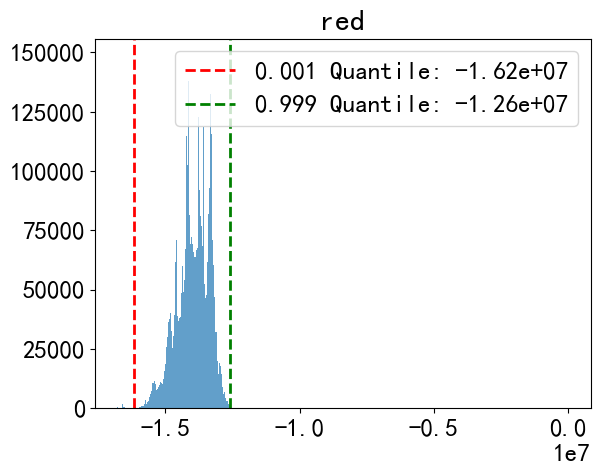

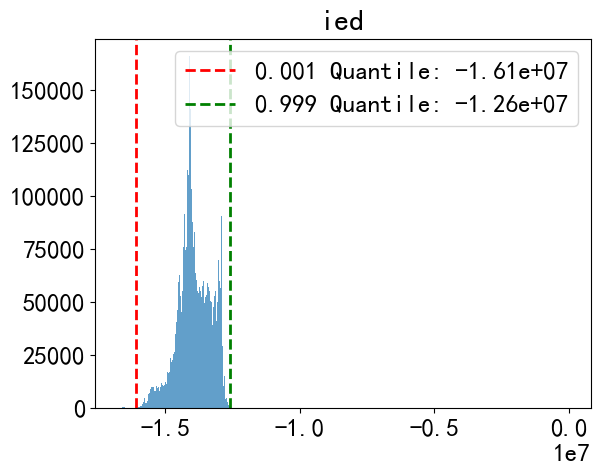

In [28]:
import numpy as np
import matplotlib.pyplot as plt

for cn in ["red", 'ied']:
    y = -1. * df[cn].values
    l, h = 0.001, 0.999
    # 计算 0.1 和 0.9 分位数 (即 10% 和 90% 的位置)
    q_low = np.quantile(y, l)
    q_high = np.quantile(y, h)
    
    # 绘制直方图，加入 alpha 参数降低透明度，避免遮挡垂线
    plt.hist(y, bins=1000, alpha=0.7)
    
    # 绘制垂线：指定颜色、线型、宽度，并添加图例标签
    plt.axvline(q_low, color='r', linestyle='--', linewidth=2, label=f'{l} Quantile: {q_low:.2e}')
    plt.axvline(q_high, color='g', linestyle='--', linewidth=2, label=f'{h} Quantile: {q_high:.2e}')
    
    plt.title(f"{cn}")
    plt.legend()  # 显示图例，方便查看具体的截断数值
    plt.show()

red: 过滤掉 15820 个 (0.2000%)，保留 7893800 个


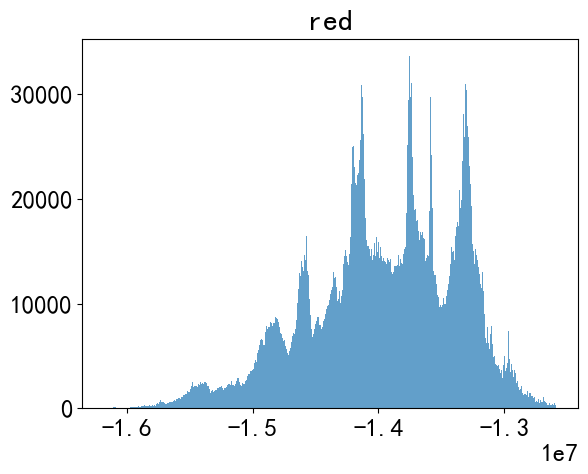

ied: 过滤掉 15820 个 (0.2000%)，保留 7893800 个


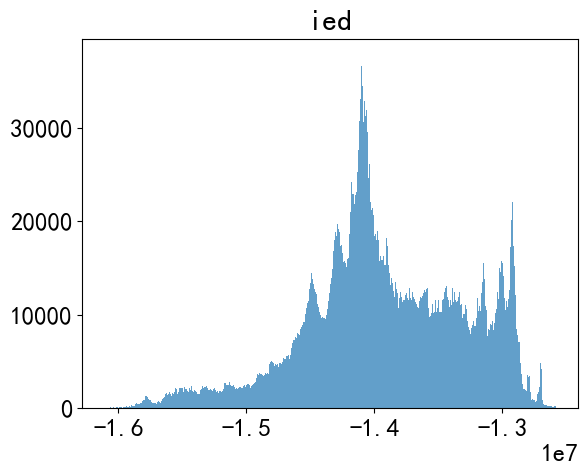

In [30]:
for cn in ["red", 'ied']:
    y = -1. * df[cn].values
    l, h = 0.001, 0.999
    q_low = np.quantile(y, l)
    q_high = np.quantile(y, h)
    
    # 筛选在 [q_low, q_high] 范围内的数据
    mask = (y >= q_low) & (y <= q_high)
    y_filtered = y[mask]
    
    # 被过滤掉的数量和占比
    filtered_count = len(y) - len(y_filtered)
    filtered_ratio = filtered_count / len(y)
    print(f"{cn}: 过滤掉 {filtered_count} 个 ({filtered_ratio:.4%})，保留 {len(y_filtered)} 个")
    
    # 绘制直方图
    plt.hist(y_filtered, bins=1000, alpha=0.7)
    plt.title(f"{cn}")
    plt.show()

In [51]:
acc_min = min(accX.min(), accY.min(), accZ.min())
acc_max = max(accX.max(), accY.max(), accZ.max())

In [52]:
y = -1. * df['ied'].values
accX = df['accX'].values
accY = df['accY'].values
accZ = df['accZ'].values

l, h = 0.001, 0.999
q_low = np.quantile(y, l)
q_high = np.quantile(y, h)

mask = (y >= q_low) & (y <= q_high)
y = y[mask]
accX = accX[mask]
accY = accY[mask]
accZ = accZ[mask]


@interact(
    start=IntSlider(min=0, max=len(y)-200, step=30, value=0, description='start idx'),
    window=IntSlider(min=200, max=7900000, step=100, value=500, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    t = np.arange(start, end) / 100.0
    
    fig, ax1 = plt.subplots(figsize=(18, 7))
    ax2 = ax1.twinx()
    
    ax1.plot(t, y[start:end], 'o-', linewidth=1, markersize=2, color='tab:blue', label='IED')
    ax2.plot(t, accX[start:end], '-', linewidth=1, color='tab:orange', label='accX', alpha=0.8)
    ax2.plot(t, accY[start:end], '-', linewidth=1, color='tab:green', label='accY', alpha=0.8)
    ax2.plot(t, accZ[start:end], '-', linewidth=1, color='tab:purple', label='accZ', alpha=0.8)
    
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('IED (high-pass)', color='tab:blue')
    ax2.set_ylabel('acc (X/Y/Z)', color='tab:orange')
    
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    ax1.set_title(f'Sample {start}~{end} ({window} samples / {window/100:.1f}s)')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.set_ylim((y.min(), y.max()))
    ax2.set_ylim((acc_min, acc_max))
    
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=0, description='start idx', max=7893600, step=30), IntSlider(value=500, …

In [32]:
y = -1. * df['red'].values
l, h = 0.001, 0.999
q_low = np.quantile(y, l)
q_high = np.quantile(y, h)

# 筛选在 [q_low, q_high] 范围内的数据
mask = (y >= q_low) & (y <= q_high)
y = y[mask]

@interact(
    start=IntSlider(min=0, max=len(y)-200, step=30, value=0, description='start idx'),
    window=IntSlider(min=200, max=7900000, step=100, value=500, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    t = np.arange(start, end) / 100.0
    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(t, y[start:end], 'o-', linewidth=1, markersize=2)
    # ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IED (high-pass)')
    # ax.set_ylim([ymin, ymax])

    ax.set_title(f'Sample {start}~{end} ({window} samples / {window/100:.1f}s)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='start idx', max=7893600, step=30), IntSlider(value=500, …

In [53]:
df = pd.read_csv("../feature_extraction/bupt_maydat.csv")
df.dropna(inplace=True)

y = df.ied
l, h = 0.001, 0.999
q_low = np.quantile(y, l)
q_high = np.quantile(y, h)

mask = (y >= q_low) & (y <= q_high)
df_filtered = df[mask]




In [55]:
df_filtered.to_csv("may_filtered.csv", index=False)